In [1]:
import numpy as np
import pandas as pd, os, datetime

# Statistical analysis
from tslearn.metrics import cdist_dtw
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# Plottting
import matplotlib.pyplot as plt

# Import the loader function
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the

Dask dashboard: /proxy/8787/status


2025-12-16 09:00:28,794 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 303c94ee39429c3f2da4aa497ec99c5b initialized by task ('shuffle-transfer-303c94ee39429c3f2da4aa497ec99c5b', 2) executed on worker tcp://127.0.0.1:42415
2025-12-16 09:00:37,187 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 303c94ee39429c3f2da4aa497ec99c5b deactivated due to stimulus 'task-finished-1765836037.1805587'
2025-12-16 09:00:37,469 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 89e9509ce1489bcd80a5aabb8e796b05 initialized by task ('shuffle-transfer-89e9509ce1489bcd80a5aabb8e796b05', 2) executed on worker tcp://127.0.0.1:42415
2025-12-16 09:00:38,923 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 89e9509ce1489bcd80a5aabb8e796b05 deactivated due to stimulus 'task-finished-1765836038.6274838'


In [2]:
df, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="daily",
    ftype=["Wind"],
    apply_remove_negatives=True,
    apply_remove_wind_zeros=True,
    apply_min_heatwave_days=True,
    min_heatwave_days_threshold=40,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.09 sec
Select group: 0.00 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:168: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp_pd_jittered = grp_pd.groupby(['lat', 'lon'], group_keys=False).apply(


Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 0.19 seconds
filter_and_clean: 0.01 seconds
type_conversion_and_dropna: 0.03 seconds
date_filter: 0.01 seconds
hw_tseries_filter: 10.65 seconds
aggregate_daily: 0.03 seconds
jitter: 0.22 seconds
final_merge: 0.25 seconds
compute: 49.60 seconds
--- END REPORT ---

Process group: 64.13 sec

--- DEBUG: Calculated Heatwave Days per Generator ---
DUID
MUSSELR1    334
SAPHWF1     206
WRWF1       201
HALLWF2     187
HALLWF1     187
GUNNING1    178
WOODLWN1    171
LKBONNY2    167
GULLRWF1    164
NBHWF1      162
WATERLWF    161
CLEMGPWF    158
SNOWTWN1    157
LKBONNY3    156
BLUFF1      151
TARALGA1    150
MEWF1       143
BOCORWF1    126
BODWF1      122
STWF1       115
SNOWNTH1    109
OAKLAND1    107
COOPGWF1    103
BALDHWF1    101
MACARTH1     98
HDWF1        98
HDWF2        92
HDWF3        92
SNOWSTH1     89
MERCER01     84
GRANWF1      84
CROOKWF2     76
ARWF1        72
K

In [5]:
df = data

In [6]:
df_coords = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/gen_info.csv")[["DUID", "lat","lon"]]

In [7]:
events = (
    df[df["EHF_flag"] == 1]
    .groupby("DUID")["time"]
    .apply(list)
)

In [8]:
def temporal_jaccard(a, b, tol_days=3):
    """
    a, b: lists of timestamps
    tol_days: tolerance window in days
    """
    a = np.array(a, dtype="datetime64[D]")
    b = np.array(b, dtype="datetime64[D]")

    matched = 0
    for t in a:
        if np.any(np.abs(b - t).astype(int) <= tol_days):
            matched += 1

    union = len(a) + len(b) - matched
    return 1 - matched / union if union > 0 else 1.0  # distance

In [9]:
duids = events.index.tolist()
n = len(duids)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i+1, n):
        d = temporal_jaccard(events.iloc[i], events.iloc[j], tol_days=0)
        dist_matrix[i, j] = dist_matrix[j, i] = d

/jobfs/156759316.gadi-pbs/ipykernel_3032091/3136726851.py:6: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  a = np.array(a, dtype="datetime64[D]")
/jobfs/156759316.gadi-pbs/ipykernel_3032091/3136726851.py:7: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  b = np.array(b, dtype="datetime64[D]")


In [42]:
Z = linkage(squareform(dist_matrix), method="average")
labels = fcluster(Z, t=6, criterion="maxclust")

clusters = pd.DataFrame({"DUID": duids, "cluster": labels})

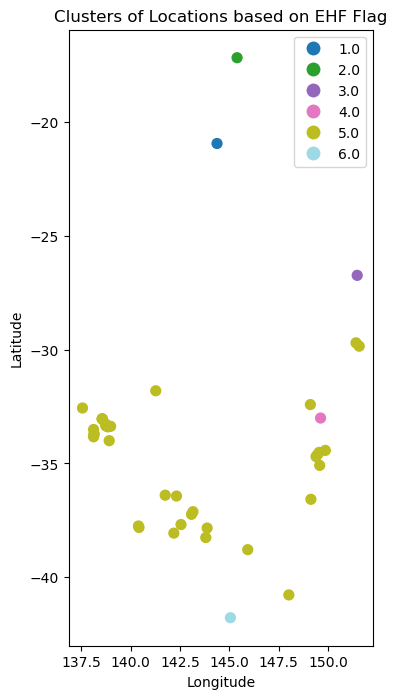

In [43]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

df_map = df_coords.merge(clusters, on="DUID", how="left")

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map.lon, df_map.lat),
    crs="EPSG:4326"  # WGS84
)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(
    column="cluster",   # color by cluster
    categorical=True,   # treat clusters as categories
    cmap="tab20",       # nice categorical colormap
    legend=True,
    markersize=50,
    ax=ax
)

ax.set_title("Clusters of Locations based on EHF Flag")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


In [44]:
# Merge cluster info into main df
df_merged = df.merge(clusters, on="DUID")

# Compute cluster-level status per day
cluster_status = df_merged.groupby(['cluster','time'])['EHF_flag'].max().reset_index()
cluster_status = cluster_status.rename(columns={'EHF_flag': 'EHF_flag_cluster'})

# Merge cluster status back (for reference)
df_merged = df_merged.merge(cluster_status, on=['cluster','time'])

# Pivot: cluster status per day (wide)
cluster_status_wide = cluster_status.pivot(index='time', columns='cluster', values='EHF_flag_cluster')

# Prepare result storage
clusters_list = clusters['cluster'].unique()
spillover = []

for active_cluster in clusters_list:
    # days when this cluster is active
    active_days = cluster_status_wide[cluster_status_wide[active_cluster]==1].index
    
    for target_cluster in clusters_list:
        # skip self if desired, or include to see own effect
        # if target_cluster == active_cluster:
        #     continue
        
        # demand in target cluster on active days
        target_duids = clusters.loc[clusters['cluster']==target_cluster, 'DUID']
        mask = (df_merged['DUID'].isin(target_duids)) & (df_merged['time'].isin(active_days))
        event_demand = df_merged.loc[mask, 'TOTALMWh'].mean()
        
        # baseline: demand on days when active_cluster is 0
        inactive_days = cluster_status_wide[cluster_status_wide[active_cluster]==0].index
        mask_base = (df_merged['DUID'].isin(target_duids)) & (df_merged['time'].isin(inactive_days))
        baseline_demand = df_merged.loc[mask_base, 'TOTALMWh'].mean()
        
        # percentage change
        pct_change = (event_demand - baseline_demand) / baseline_demand * 100 if baseline_demand != 0 else np.nan
        
        spillover.append({
            'active_cluster': active_cluster,
            'target_cluster': target_cluster,
            'pct_change': pct_change
        })

spillover_df = pd.DataFrame(spillover)
print(spillover_df)

    active_cluster  target_cluster  pct_change
0                5               5   -8.766414
1                5               3   -4.331074
2                5               4  -14.045075
3                5               6  -21.656792
4                5               1    9.355137
5                5               2  -22.086808
6                3               5   -2.268260
7                3               3  -33.806764
8                3               4  -19.823597
9                3               6  -42.195497
10               3               1   17.328832
11               3               2  -41.502657
12               4               5  -14.287875
13               4               3   -7.838095
14               4               4  -11.665400
15               4               6  -12.769939
16               4               1   49.061813
17               4               2  -10.563173
18               6               5   -2.922732
19               6               3    5.693626
20           

In [45]:
cluster_coords = df_coords.merge(clusters, on="DUID") \
    .groupby('cluster')[['lat', 'lon']].mean().reset_index()

In [46]:
spillover_map = spillover_df.merge(
    cluster_coords.rename(columns={'lat':'lat_active','lon':'lon_active'}),
    left_on='active_cluster', right_on='cluster'
).merge(
    cluster_coords.rename(columns={'lat':'lat_target','lon':'lon_target'}),
    left_on='target_cluster', right_on='cluster',
    suffixes=('_active','_target')
)

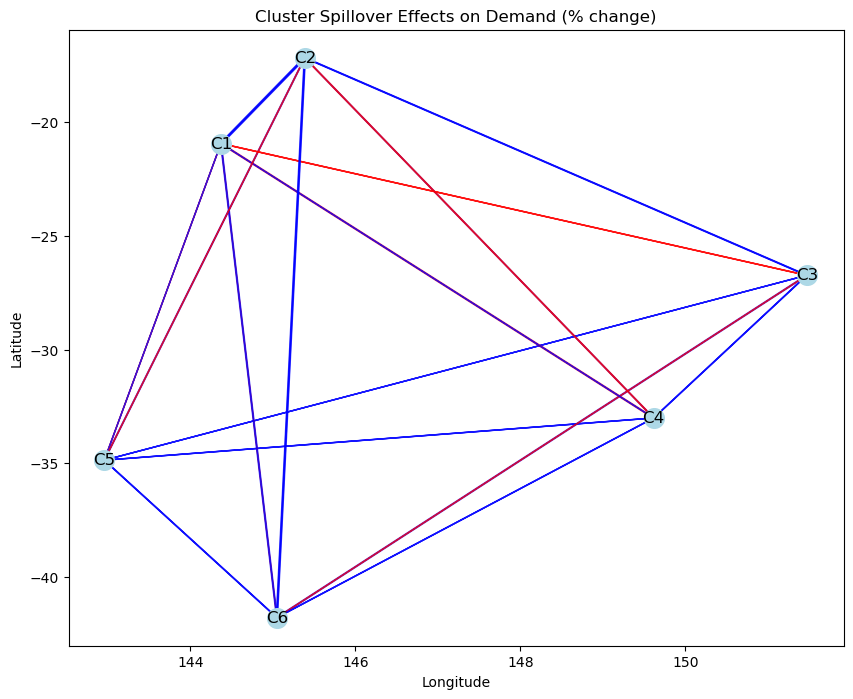

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

# Plot cluster locations
plt.scatter(cluster_coords['lon'], cluster_coords['lat'], s=200, color='lightblue', zorder=2)
for i, row in cluster_coords.iterrows():
    plt.text(row['lon'], row['lat'], f"C{int(row['cluster'])}", fontsize=12,
             ha='center', va='center', zorder=3)

# Plot arrows for spillovers
for _, row in spillover_map.iterrows():
    if np.isnan(row['pct_change']) or row['pct_change']==0:
        continue
    # scale arrow width
    width = max(abs(row['pct_change']) / 5, 0.5)
    color = 'red' if row['pct_change']>0 else 'blue'
    
    plt.arrow(
        row['lon_active'], row['lat_active'],
        row['lon_target']-row['lon_active'],
        row['lat_target']-row['lat_active'],
        width=0.002*width,
        color=color,
        alpha=0.7,
        length_includes_head=True
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Cluster Spillover Effects on Demand (% change)")
plt.show()


In [48]:
# Cluster coordinates
cluster_coords = df_coords.merge(clusters, on="DUID") \
    .groupby('cluster')[['lat', 'lon']].mean().reset_index()

# Merge spillover effects
spillover_map = spillover_df.merge(
    cluster_coords.rename(columns={'lat':'lat_active','lon':'lon_active'}),
    left_on='active_cluster', right_on='cluster'
).merge(
    cluster_coords.rename(columns={'lat':'lat_target','lon':'lon_target'}),
    left_on='target_cluster', right_on='cluster',
    suffixes=('_active','_target')
)

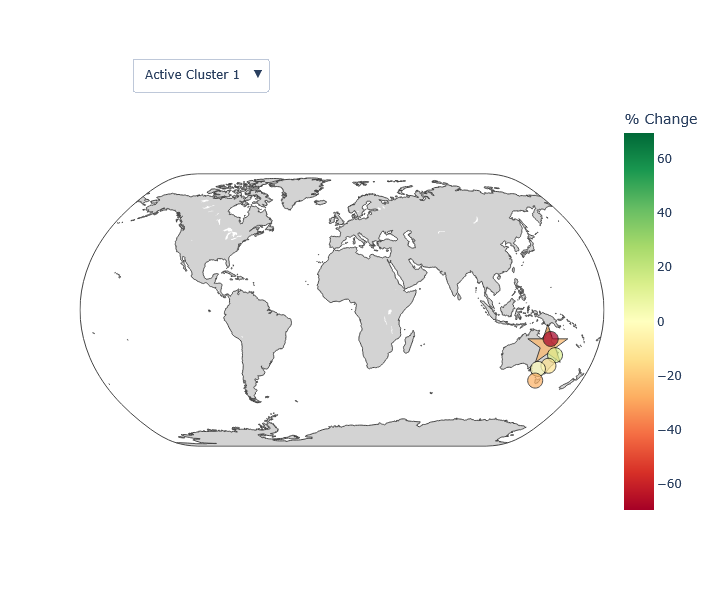

In [49]:
import plotly.graph_objects as go
import numpy as np

# Initial active cluster
active_cluster = cluster_coords['cluster'].iloc[0]

# Compute % change for all clusters
df_active = spillover_map[spillover_map['active_cluster']==active_cluster]
pct_dict = df_active.set_index('target_cluster')['pct_change'].to_dict()
cluster_coords['pct_change'] = cluster_coords['cluster'].map(pct_dict).fillna(0)

# Base trace for all clusters
marker_size = np.where(cluster_coords['cluster']==active_cluster, 30, 15)
marker_symbol = np.where(cluster_coords['cluster']==active_cluster, 'star', 'circle')

fig = go.Figure(go.Scattergeo(
    lon = cluster_coords['lon'],
    lat = cluster_coords['lat'],
    text = ["Cluster {}<br>% Change: {:.2f}".format(c,pct) for c,pct in zip(cluster_coords['cluster'], cluster_coords['pct_change'])],
    mode = 'markers',
    marker = dict(
        size = marker_size,
        symbol = marker_symbol,
        color = cluster_coords['pct_change'],
        colorscale = 'RdYlGn',
        cmin = -max(abs(cluster_coords['pct_change'])),
        cmax = max(abs(cluster_coords['pct_change'])),
        colorbar = dict(title='% Change'),
        line = dict(width=1, color='black')
    )
))

# Dropdown to update active cluster
buttons = []
for active in cluster_coords['cluster']:
    df_active = spillover_map[spillover_map['active_cluster']==active]
    pct_dict = df_active.set_index('target_cluster')['pct_change'].to_dict()
    pct_change = cluster_coords['cluster'].map(pct_dict).fillna(0)
    
    size_marker = np.where(cluster_coords['cluster']==active, 30, 15)
    symbol_marker = np.where(cluster_coords['cluster']==active, 'star', 'circle')
    hover_text = ["Cluster {}<br>% Change: {:.2f}".format(c,pct) for c,pct in zip(cluster_coords['cluster'], pct_change)]
    
    buttons.append(dict(
        label=f"Active Cluster {active}",
        method="update",
        args=[{
            "marker.color": [pct_change],
            "marker.size": [size_marker],
            "marker.symbol": [symbol_marker],
            "text": [hover_text]
        }]
    ))

fig.update_layout(
    updatemenus=[dict(buttons=buttons, x=0.1, y=1.1, xanchor='left', yanchor='top')],
    geo=dict(
        scope='world',
        projection_type='natural earth',
        showland=True,
        landcolor="lightgray"
    ),
    width=800,
    height=600
)

fig.show()
